In [ ]:
pip install gradio

In [30]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [13]:
df = pd.read_csv("delivery_data.csv")
df.head()

,distance_km,order_size,weight_kg,num_items,warehouse_processing_hours,courier_speed_kmph,traffic_index,weather_severity,pickup_hour,day_of_week,is_holiday,priority_flag,delivery_time_hours
0,3.75,3,3.12,3,0.83,41.20,0.266,0,13,1,0,0,2.165
1,24.08,2,2.77,2,2.16,47.88,0.403,0,9,3,0,0,4.188
2,10.53,1,1.28,1,0.29,48.73,0.225,0,18,0,0,0,0.165
3,7.30,5,5.16,5,0.48,50.24,0.242,0,9,4,0,1,0.494
4,1.36,2,0.46,2,0.88,25.05,0.130,0,6,0,0,0,1.199


array([[<Axes: title={'center': 'distance_km'}>,
        <Axes: title={'center': 'delivery_time_hours'}>]], dtype=object)

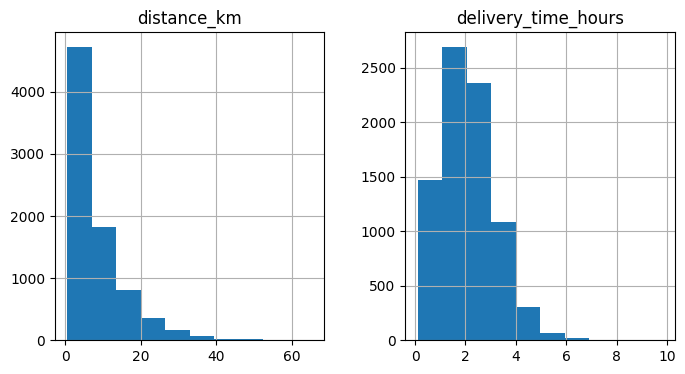

In [14]:
df.describe().T
df.isnull().sum()
# histograms
df[['distance_km','delivery_time_hours']].hist(figsize=(8,4))

In [21]:
pickup_hour = 14  # example
hour_sin = np.sin(2 * np.pi * pickup_hour / 24)
hour_cos = np.cos(2 * np.pi * pickup_hour / 24)


In [16]:
X = df.drop(columns=["delivery_time_hours"])
y = df["delivery_time_hours"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [17]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=150, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.08, max_depth=6, random_state=RANDOM_SEED)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / np.clip(y_test, 1e-6, None))) * 100
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE%": mape}
    joblib.dump(model, f"{name}_delivery_model.pkl")
pd.DataFrame(results).T.round(4)


,MAE,RMSE,R2,MAPE%
LinearRegression,0.5006,0.6311,0.6768,54.2311
RandomForest,0.5176,0.6453,0.6621,61.7108
GradientBoosting,0.5053,0.6300,0.6779,58.9016


In [18]:
rf = models['RandomForest']
fi = pd.DataFrame({"feature": X.columns, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
fi.head(12)

,feature,importance
4,warehouse_processing_hours,0.503219
0,distance_km,0.152528
6,traffic_index,0.075820
7,weather_severity,0.064265
2,weight_kg,0.057626
5,courier_speed_kmph,0.044961
11,priority_flag,0.018008
9,day_of_week,0.015877
13,hour_cos,0.015000
12,hour_sin,0.014840


In [19]:
best = min(results.keys(), key=lambda k: results[k]["MAE"])
joblib.dump(models[best], "delivery_time_model.pkl")
print("Best:", best)

Best: LinearRegression


In [23]:
input_df = pd.DataFrame([{
    "distance_km": 12.5,
    "order_size": 2,
    "weight_kg": 1.5,
    "num_items": 3,
    "warehouse_processing_hours": 1.2,
    "courier_speed_kmph": 40,
    "traffic_index": 0.3,
    "weather_severity": 1,
    "day_of_week": 2,
    "is_holiday": 0,
    "priority_flag": 1,
    "hour_sin": hour_sin,
    "hour_cos": hour_cos
}])


In [25]:
loaded.feature_names_in_


array(['distance_km', 'order_size', 'weight_kg', 'num_items',
       'warehouse_processing_hours', 'courier_speed_kmph',
       'traffic_index', 'weather_severity', 'pickup_hour', 'day_of_week',
       'is_holiday', 'priority_flag', 'hour_sin', 'hour_cos'],
      dtype=object)

In [26]:
import numpy as np
import pandas as pd

pickup_hour = 14  # user input (0–23)

hour_sin = np.sin(2 * np.pi * pickup_hour / 24)
hour_cos = np.cos(2 * np.pi * pickup_hour / 24)

input_df = pd.DataFrame([[
    12.5,   # distance_km
    2,      # order_size
    1.5,    # weight_kg
    3,      # num_items
    1.2,    # warehouse_processing_hours
    40,     # courier_speed_kmph
    0.3,    # traffic_index
    1,      # weather_severity
    pickup_hour,
    2,      # day_of_week (0=Mon)
    0,      # is_holiday
    1,      # priority_flag
    hour_sin,
    hour_cos
]], columns=loaded.feature_names_in_)


In [29]:
pred_hours = loaded.predict(input_df)[0]
print("Predicted delivery time (hours):", pred_hours)


Predicted delivery time (hours): 2.1331994383843975


In [31]:
def predict_delivery_time(
    distance_km,
    order_size,
    weight_kg,
    num_items,
    warehouse_processing_hours,
    courier_speed_kmph,
    traffic_index,
    weather_severity,
    pickup_hour,
    day_of_week,
    is_holiday,
    priority_flag
):
    # Cyclical encoding
    hour_sin = np.sin(2 * np.pi * pickup_hour / 24)
    hour_cos = np.cos(2 * np.pi * pickup_hour / 24)

    # Create DataFrame with EXACT feature order
    input_df = pd.DataFrame([[
        distance_km,
        order_size,
        weight_kg,
        num_items,
        warehouse_processing_hours,
        courier_speed_kmph,
        traffic_index,
        weather_severity,
        pickup_hour,
        day_of_week,
        is_holiday,
        priority_flag,
        hour_sin,
        hour_cos
    ]], columns=loaded.feature_names_in_)

    prediction = loaded.predict(input_df)[0]
    return f"Predicted Delivery Time: {round(prediction, 2)} hours"


In [32]:
interface = gr.Interface(
    fn=predict_delivery_time,
    inputs=[
        gr.Number(label="Distance (km)", value=10),
        gr.Number(label="Order Size", value=2),
        gr.Number(label="Weight (kg)", value=1.5),
        gr.Number(label="Number of Items", value=3),
        gr.Number(label="Warehouse Processing Time (hours)", value=1.0),
        gr.Number(label="Courier Speed (km/h)", value=40),
        gr.Slider(0, 1, step=0.1, label="Traffic Index"),
        gr.Radio([0, 1, 2], label="Weather Severity (0=Clear, 1=Rain, 2=Storm)", value=0),
        gr.Slider(0, 23, step=1, label="Pickup Hour"),
        gr.Slider(0, 6, step=1, label="Day of Week (0=Mon)"),
        gr.Radio([0, 1], label="Is Holiday", value=0),
        gr.Radio([0, 1], label="Priority Delivery", value=0)
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Delivery Time Prediction System",
    description="Predict delivery time using machine learning based on order, traffic, and time factors."
)


In [33]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f302ab2eea9e0c4af0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
